# Week 2 - ML Pipeline on Tesla Sales & Price Data

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Data Loading

In [ ]:
csv_path = os.path.join('Data', 'tesla_deliveries_dataset_2015_2025.csv')
df = pd.read_csv(csv_path)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.shape

(2640, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Data Preprocessing

In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (2640, 12)


In [ ]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(0).astype(int)
df['Month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1).astype(int)
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1), errors='coerce')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [10]:
print("Unique Regions:", df['Region'].unique())
print("Unique Models:", df['Model'].unique())
print("Unique Source Types:", df['Source_Type'].unique())

Unique Regions: <ArrowStringArray>
['Europe', 'Asia', 'North America', 'Middle East']
Length: 4, dtype: str
Unique Models: <ArrowStringArray>
['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Length: 5, dtype: str
Unique Source Types: <ArrowStringArray>
['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']
Length: 3, dtype: str


## Exploratory Data Analysis

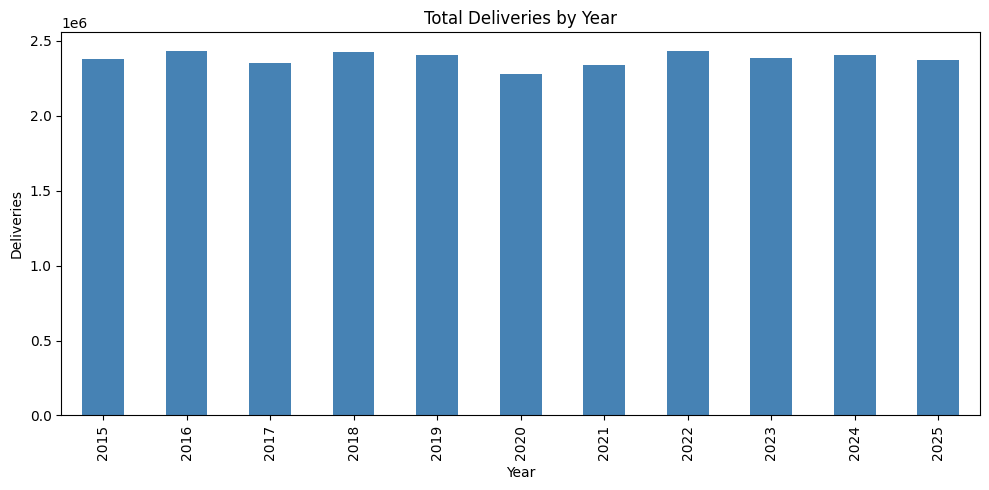

In [11]:
plt.figure(figsize=(10, 5))
df.groupby('Year')['Estimated_Deliveries'].sum().plot(kind='bar', color='steelblue')
plt.title('Total Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

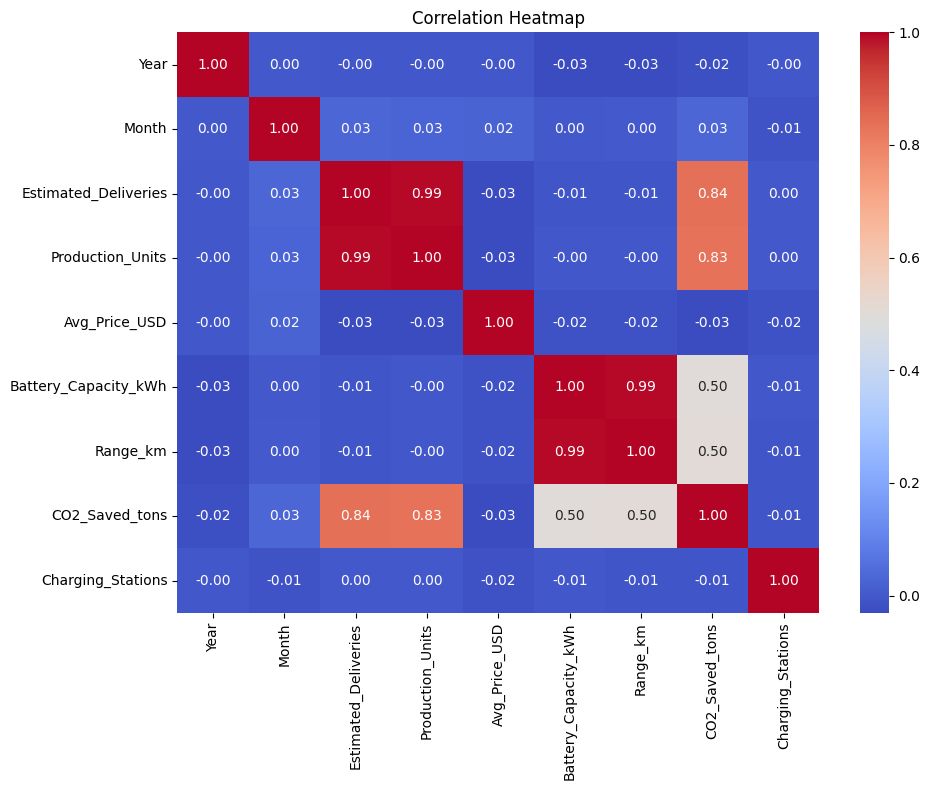

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
df['Quarter'] = ((df['Month'] - 1) // 3 + 1).clip(lower=1)
df['Delivery_Production_Ratio'] = np.where(df['Production_Units'] == 0, 0, df['Estimated_Deliveries'] / df['Production_Units'])
df['Price_per_kWh'] = np.where(df['Battery_Capacity_kWh'] == 0, 0, df['Avg_Price_USD'] / df['Battery_Capacity_kWh'])
df['CO2_per_Delivery'] = np.where(df['Estimated_Deliveries'] == 0, 0, df['CO2_Saved_tons'] / df['Estimated_Deliveries'])
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Delivery_Production_Ratio,Price_per_kWh,CO2_per_Delivery
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,0.984600,773.952250,0.105600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,0.911864,829.408667,0.065699
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,0.915334,1437.650244,0.072000
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,0.896594,744.124250,0.106799
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,0.914087,957.056500,0.099150


In [ ]:
for col in ['Region', 'Model', 'Source_Type']:
    df[col] = df[col].fillna('Unknown').astype(str)
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()
df['Region_encoded'] = le_region.fit_transform(df['Region'])
df['Model_encoded'] = le_model.fit_transform(df['Model'])
df['Source_encoded'] = le_source.fit_transform(df['Source_Type'])

In [15]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Delivery_Production_Ratio,Price_per_kWh,CO2_per_Delivery,Region_encoded,Model_encoded,Source_encoded
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,0.984600,773.952250,0.105600,1,2,1
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,0.911864,829.408667,0.065699,0,3,2
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,0.915334,1437.650244,0.072000,3,3,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,0.896594,744.124250,0.106799,3,1,2
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,0.914087,957.056500,0.099150,2,4,0


## Regression Modeling

In [ ]:
candidate_features = ['Year', 'Month', 'Region_encoded', 'Model_encoded', 'Production_Units',
                      'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Quarter',
                      'Delivery_Production_Ratio', 'Price_per_kWh']
features = [c for c in candidate_features if c in df.columns]
X = df[features].fillna(0)
y = df['Avg_Price_USD'].fillna(df['Avg_Price_USD'].median())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}
results = []
def evaluate(y_true, preds):
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    return round(rmse, 2), round(mae, 2), round(r2, 4)
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse, mae, r2 = evaluate(y_test, preds)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)
results_df

,Model,RMSE,MAE,R2
3,Random Forest,692.03,228.90,0.9987
4,Gradient Boosting,1368.52,964.65,0.9950
0,Linear Regression,6045.69,4927.96,0.9031
2,Lasso,6045.03,4927.99,0.9031
1,Ridge,6045.21,4925.13,0.9031


In [19]:
best_model_name = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
print(f"Best model: {best_model_name}")

Best model: Random Forest


## Hyperparameter Tuning

In [ ]:
from scipy.stats import randint
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': randint(2, 10)
}
rand_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
rand_search.fit(X_train, y_train)
print(f"Best params: {rand_search.best_params_}")
print(f"Best R2 score: {rand_search.best_score_:.4f}")

Best params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best R2 score: 0.9987


In [21]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

RMSE: 661.03
MAE: 221.16
R2: 0.9988


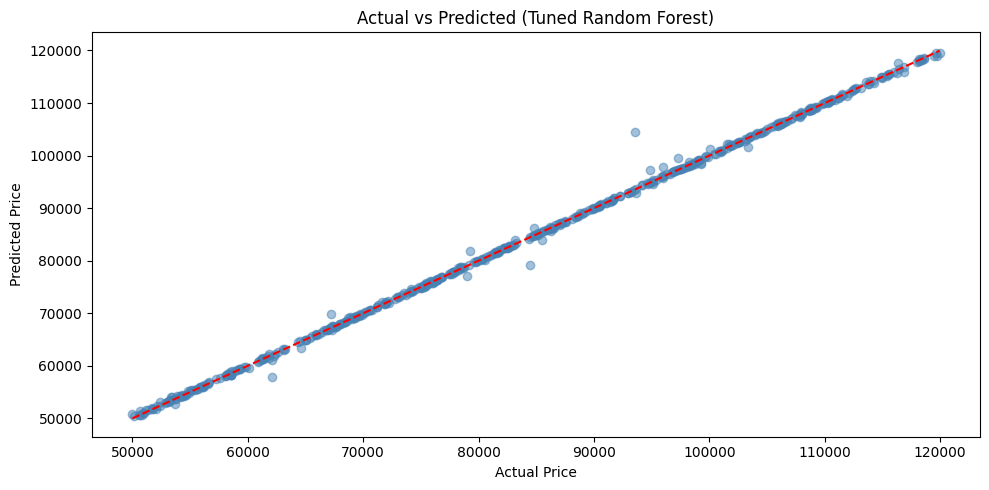

In [22]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (Tuned Random Forest)')
plt.tight_layout()
plt.show()

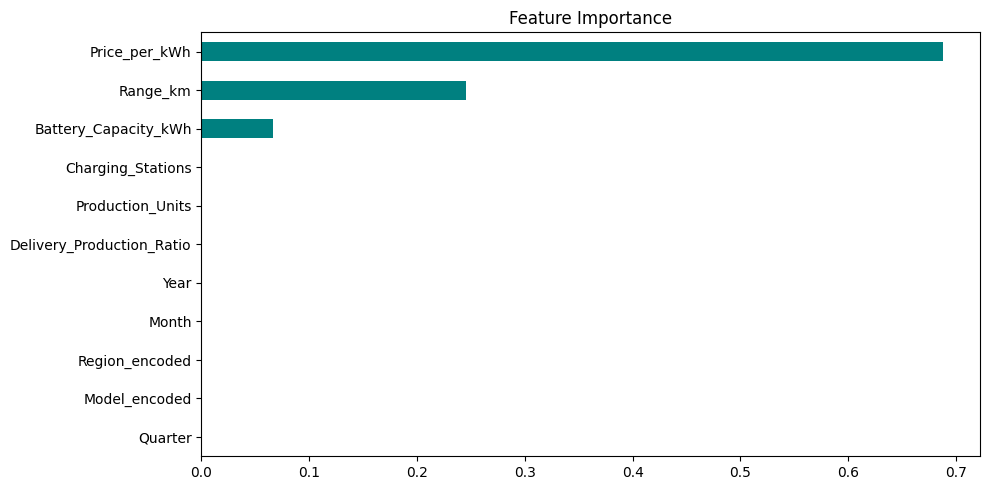

In [23]:
feat_imp = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Time Series Forecasting

In [ ]:
ts_data = df.dropna(subset=['Date']).groupby('Date')['Estimated_Deliveries'].sum().sort_index()
ts_data = ts_data.asfreq('MS', method='ffill')
ts_data.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Freq: MS, Name: Estimated_Deliveries, dtype: int64

In [25]:
train_ts = ts_data[:int(len(ts_data) * 0.8)]
test_ts = ts_data[int(len(ts_data) * 0.8):]
print(f"Train size: {len(train_ts)}, Test size: {len(test_ts)}")

Train size: 105, Test size: 27


In [26]:
hw_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast = hw_model.forecast(len(test_ts))

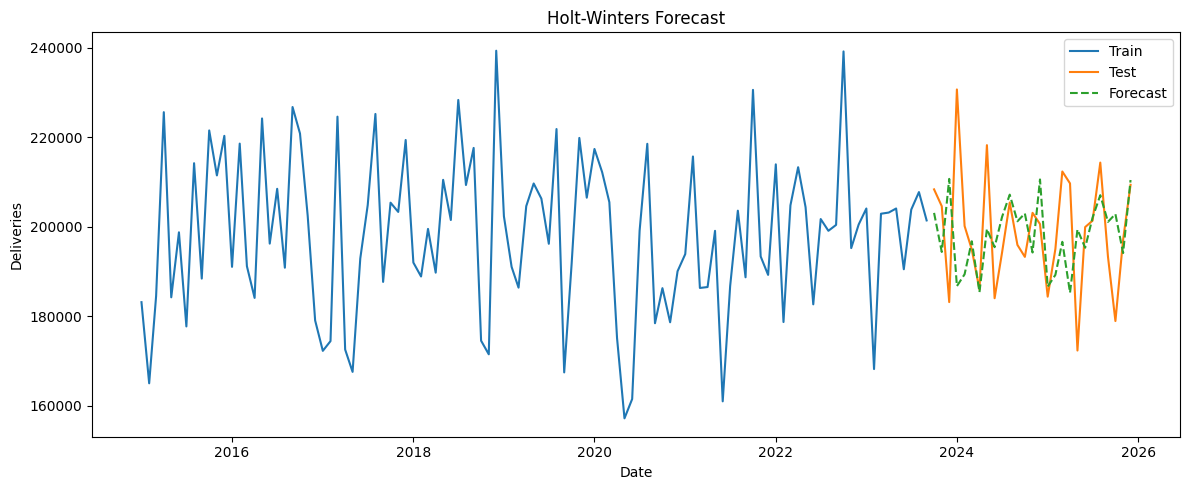

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(train_ts, label='Train')
plt.plot(test_ts, label='Test')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.title('Holt-Winters Forecast')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
ts_mae = mean_absolute_error(test_ts, forecast)
print(f"Forecast RMSE: {ts_rmse:.2f}")
print(f"Forecast MAE: {ts_mae:.2f}")

Forecast RMSE: 15049.85
Forecast MAE: 11011.89


## Conclusion

- Loaded and cleaned the Tesla deliveries dataset
- Performed EDA to understand trends across years, models and regions
- Created new features like price per kWh, delivery ratio, quarter etc.
- Trained multiple regression models to predict average price
- Tuned Random Forest using GridSearchCV for better performance
- Used Holt-Winters exponential smoothing for time series forecasting of deliveries